# Praca magisterska

### Zastosowanie metod nauczania maszynowego i równań różniczkowych z opóźnionym argumentem czasu do stworzenia modelu wzrostu komórek nowotworowych

Bioinformatyka 2026 \
Jadwiga Krząstek \
Część 1: Nauczanie maszynowe - wybór modelu segmentacyjnego

Prosty U-net (model 1)

Uruchomienie: run all cells

In [43]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, TensorDataset
import random
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support
from skimage.io import imsave

Liczba próbek: 680
Przykładowe ID: ['00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552', '003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1', '00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e']
Kształt obrazu: (256, 256, 4)


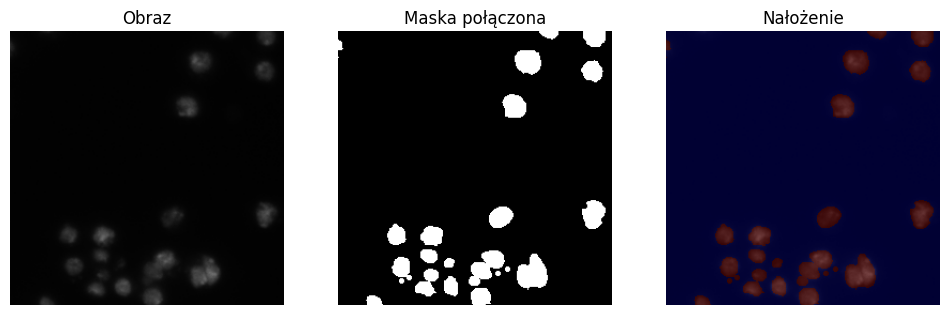

Epoka 1/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [01:53<00:00,  1.20it/s]


[Epoka 1] TrainLoss=0.6645, ValLoss=0.6139, Dice=0.0000


Epoka 2/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [01:52<00:00,  1.21it/s]


[Epoka 2] TrainLoss=0.5859, ValLoss=0.5531, Dice=0.0000


Epoka 3/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [01:56<00:00,  1.17it/s]


...

[Epoka 23] TrainLoss=0.2831, ValLoss=0.2675, Dice=0.7256


Epoka 24/25: 100%|███████████████████████████████████████████████████████████████████| 136/136 [00:55<00:00,  2.47it/s]


[Epoka 24] TrainLoss=0.2810, ValLoss=0.2724, Dice=0.7348


Epoka 25/25: 100%|███████████████████████████████████████████████████████████████████| 136/136 [00:55<00:00,  2.46it/s]


[Epoka 25] TrainLoss=0.2806, ValLoss=0.2706, Dice=0.7284


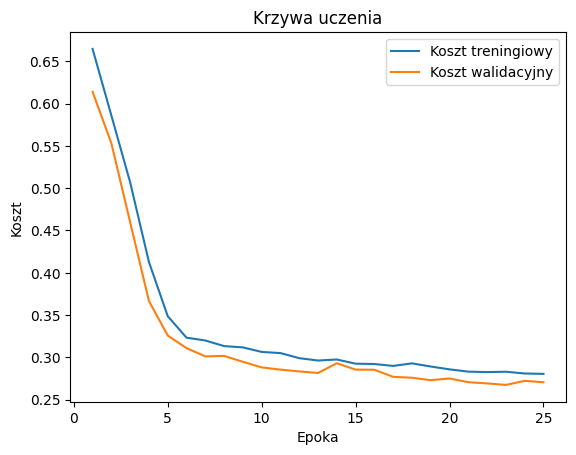

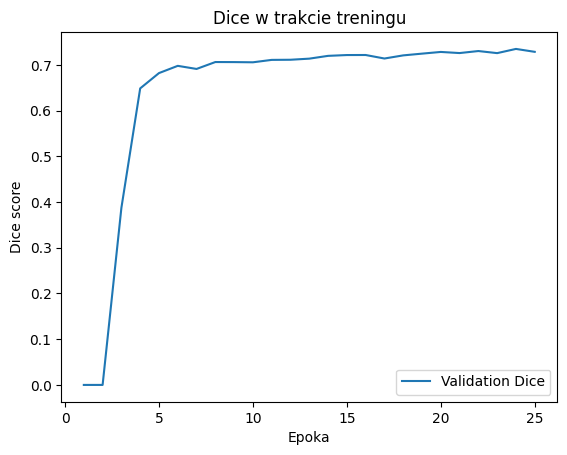

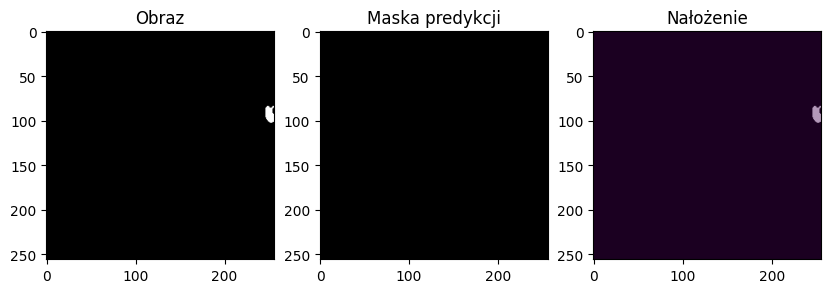

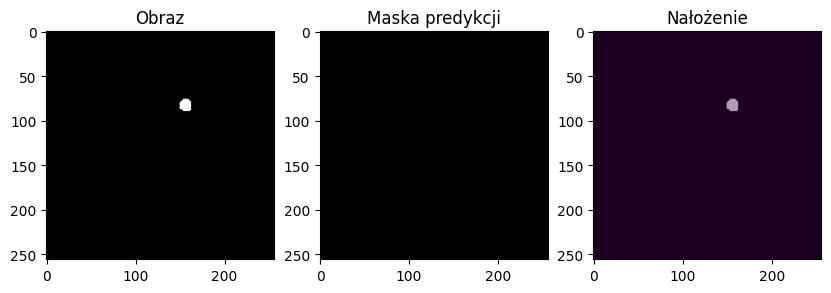

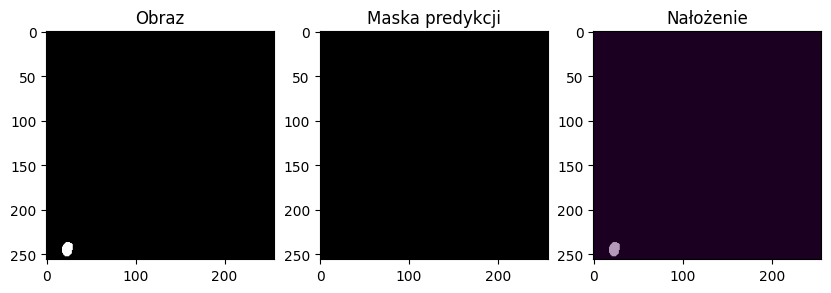

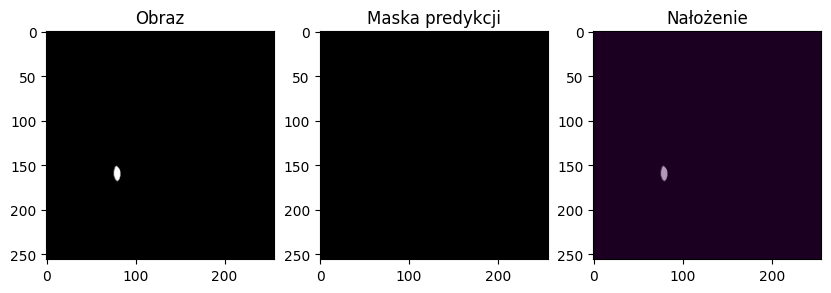

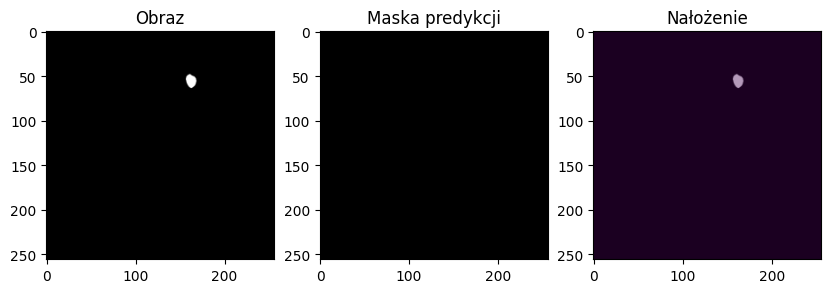

Dice: 0.424, IoU: 0.269, Precision: 0.998, Recall: 0.269
                                                path      dice       iou  \
0  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.861973  0.757427   
1  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.829635  0.708869   
2  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.752141  0.602745   
3  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.757491  0.609646   
4  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.812486  0.684190   

   precision    recall  
0   0.886607  0.838670  
1   0.747923  0.931391  
2   0.954579  0.620542  
3   0.886315  0.661363  
4   0.908318  0.734945  

Średnie wyniki:
dice         0.802745
iou          0.672575
precision    0.876749
recall       0.757382
dtype: float64


In [59]:
DATA_DIR = 'C:/Users/jadwi/data-science-bowl-2018/stage1_train'

ids = os.listdir(DATA_DIR)
print(f"Liczba próbek: {len(ids)}")
print("Przykładowe ID:", ids[:3])

sample_id = ids[0]

img_path = os.path.join(DATA_DIR, sample_id, "images", sample_id + ".png")
image = np.array(Image.open(img_path))

print("Kształt obrazu:", image.shape)

mask_dir = os.path.join(DATA_DIR, sample_id, "masks")
mask_files = os.listdir(mask_dir)

combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)

for mf in mask_files:
    mask_path = os.path.join(mask_dir, mf)
    mask = np.array(Image.open(mask_path))
    combined_mask = np.maximum(combined_mask, mask)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Obraz")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Maska połączona")
plt.imshow(combined_mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Nałożenie")
plt.imshow(image)
plt.imshow(combined_mask, cmap="jet", alpha=0.4)
plt.axis("off")

plt.show()

class KaggleDataset(Dataset): #klasa z funkcjami wczytującymi próbkę, przygotowanie do odpowiedniego formatu obrazów i masek, zbudowanie listy obrazów i masek
    def __init__(self, ids, data_dir, img_size=256):
        self.ids = ids
        self.data_dir = data_dir
        self.img_size = img_size

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sid = self.ids[idx]

        #obraz
        img_path = os.path.join(self.data_dir, sid, "images", sid + ".png")
        img = Image.open(img_path).convert("L")
        img = img.resize((self.img_size, self.img_size))
        img = np.array(img, dtype=np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)  #(1,H,W)

        #maska
        mask_dir = os.path.join(self.data_dir, sid, "masks")
        mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)

        for mf in os.listdir(mask_dir):
            m = Image.open(os.path.join(mask_dir, mf)).convert("L")
            m = m.resize((self.img_size, self.img_size))
            m = np.array(m) > 0
            mask = np.logical_or(mask, m)
            

        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img, mask

DATA_DIR = "C:/Users/jadwi/data-science-bowl-2018/stage1_train"

ids = os.listdir(DATA_DIR)
ids = sorted(ids)

train_ids, val_ids = train_test_split(
    ids,
    test_size=0.2,
    random_state=42
)

train_dataset = KaggleDataset(train_ids, DATA_DIR)
val_dataset   = KaggleDataset(val_ids, DATA_DIR)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

class BCEDiceLoss(nn.Module): #obliczanie funkcji kosztu BCE+DICE (najlepsze wyniki w przypadku ich połączenia 50-50)
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets):
        bce = self.bce(inputs, targets)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        return 0.5 * bce + 0.5 * (1 - dice)

class TestDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = load_test_image(self.image_paths[idx])
        return torch.tensor(img), self.image_paths[idx]

class SimpleSegNet(nn.Module):
    def __init__(self):
        super().__init__()

        #encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), #1 - skala szarości, 8 - ilość filtrów, 3 - krok
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        #decoder
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(16, 8, 2, stride=2),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(8, 1, 2, stride=2)
        )

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.dec1(x)
        x = self.dec2(x)
        return torch.sigmoid(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_SimpleSegNet = SimpleSegNet().to(device)
optimizer = torch.optim.Adam(model_SimpleSegNet.parameters(), lr=1e-3)
criterion = BCEDiceLoss()

num_epochs = 25

train_losses = []
val_losses = []
val_dice = []


def dice_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection) / (pred.sum() + target.sum())

from tqdm import tqdm

for epoch in range(num_epochs):
    model_SimpleSegNet.train()
    epoch_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f"Epoka {epoch+1}/{num_epochs}"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model_SimpleSegNet(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    model_SimpleSegNet.eval()
    val_loss = 0.0
    dice_total = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model_SimpleSegNet(imgs)
            val_loss += criterion(outputs, masks).item()
            dice_total += dice_score(outputs, masks).item()

    val_losses.append(val_loss / len(val_loader))
    val_dice.append(dice_total / len(val_loader))

    print(
        f"[Epoka {epoch+1}] "
        f"TrainLoss={train_losses[-1]:.4f}, "
        f"ValLoss={val_losses[-1]:.4f}, "
        f"Dice={val_dice[-1]:.4f}"
    )

epochs = range(1, num_epochs + 1)

plt.figure()

plt.plot(epochs, train_losses, label="Koszt treningiowy")
plt.plot(epochs, val_losses, label="Koszt walidacyjny")

plt.xlabel("Epoka")
plt.ylabel("Koszt")
plt.title("Krzywa uczenia")
plt.legend()

plt.show()

plt.figure()

plt.plot(epochs, val_dice, label="Validation Dice")

plt.xlabel("Epoka")
plt.ylabel("Dice score")
plt.title("Dice w trakcie treningu")
plt.legend()

plt.show()

def count_cells_from_mask(binary_mask):
    labeled, num_cells = ndi.label(binary_mask)
    return num_cells

def predict_mask11(model_SimpleSegNet, img_path, threshold=0.5):
    model_SimpleSegNet.eval()
    img = load_test_image(img_path)
    with torch.no_grad():
        pred = model_SimpleSegNet(img)

    pred = pred.squeeze().cpu().numpy()
    return (pred > threshold).astype(np.uint8)


results = []

for img_path in test_images:
    mask = predict_mask(model_SimpleSegNet, img_path)

    results.append({
        "path": img_path
    }) 


def visualize_prediction(img_path, mask):
    img = Image.open(img_path).convert("L")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap="gray")
    plt.title("Obraz")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Maska predykcji")

    plt.subplot(1,3,3)
    plt.imshow(img, cmap="gray")
    plt.imshow(mask, alpha=0.4)
    plt.title("Nałożenie")

    plt.show()

for _ in range(5):
    r = random.choice(results)
    visualize_prediction(r["path"], predict_mask(model_SimpleSegNet, r["path"])) #tu nie ma predict_mask11, to moze byc problem

def load_combined_mask(mask_dir, img_size=256):
    mask = np.zeros((img_size, img_size), dtype=np.uint8)

    for mf in os.listdir(mask_dir):
        m = Image.open(os.path.join(mask_dir, mf)).convert("L")
        m = m.resize((img_size, img_size))
        m = np.array(m) > 0

        mask = np.logical_or(mask, m)

    return mask.astype(np.uint8)

pairs = [ (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e\images\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e.png",r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e\masks"), 
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e\images\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e\masks"), 
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9\images\3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9\masks"),
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\8d9b4205ddb10fa49a2973b4f3a2dc6923407ae015081e1a52c4b4c2fe8faa53\images\8d9b4205ddb10fa49a2973b4f3a2dc6923407ae015081e1a52c4b4c2fe8faa53.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\8d9b4205ddb10fa49a2973b4f3a2dc6923407ae015081e1a52c4b4c2fe8faa53\masks"),
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\b0d6dfcc95e4d087d232378f860fc3ef9f95ea5a4c26d623a0be091f820a793f\images\b0d6dfcc95e4d087d232378f860fc3ef9f95ea5a4c26d623a0be091f820a793f.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\b0d6dfcc95e4d087d232378f860fc3ef9f95ea5a4c26d623a0be091f820a793f\masks")
        ]

pairs = []

for sid in ids[:5]:  # np. 5 przykładów
    img_path = os.path.join(DATA_DIR, sid, "images", sid + ".png")
    mask_dir = os.path.join(DATA_DIR, sid, "masks")

    pairs.append((img_path, mask_dir))

from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def dice_coef(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(y_true * y_pred)
    return (2 * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)
    
# y_true, y_pred to binarne maski (0/1), shape (N, H, W) lub spłaszczone
dice = dice_coef(y_true.flatten(), y_pred.flatten())
iou = dice / (2 - dice)
precision, recall, _, _ = precision_recall_fscore_support(y_true.flatten(), y_pred.flatten(), average='binary')

print(f"Dice: {dice:.3f}, IoU: {iou:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

results = []

for img_path, mask_dir in pairs:

    pred_mask = predict_mask11(model_SimpleSegNet, img_path)
    true_mask = load_combined_mask(mask_dir)

    y_pred = pred_mask.flatten()
    y_true = true_mask.flatten()

    dice = dice_coef(y_true, y_pred)
    iou = iou_score(y_true, y_pred)

    precision, recall, _, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    results.append({
        "path": img_path,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall
    })

df = pd.DataFrame(results)
print(df)
print("\nŚrednie wyniki:")
print(df[["dice", "iou", "precision", "recall"]].mean())



Definicja i trening dużego U-netu - 25 epok ze skip connections (model 2)

In [56]:
DATA_DIR = Path('C:/Users/jadwi/data-science-bowl-2018/stage1_train')

test_images = sorted(DATA_DIR.rglob("*.png")) #bylo jpg
ids = os.listdir(DATA_DIR)
print(f"Liczba próbek: {len(ids)}")
print("Przykładowe ID:", ids[:3])

sample_id = ids[0]

img_path = os.path.join(DATA_DIR, sample_id, "images", sample_id + ".png")
image = np.array(Image.open(img_path))

print("Kształt obrazu:", image.shape)

mask_dir = os.path.join(DATA_DIR, sample_id, "masks")
mask_files = os.listdir(mask_dir)

combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)

def dice_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection) / (pred.sum() + target.sum())


def load_test_image(path):
    img = Image.open(path).convert("L")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img, dtype=np.float32) / 255.0
    img = torch.tensor(img).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
    return img.to(DEVICE)

IMG_SIZE = 256
BATCH_SIZE = 4
NUM_EPOCHS = 1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def visualize_prediction(img_path, mask):
    img = Image.open(img_path).convert("L")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap="gray")
    plt.title("Obraz")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Maska predykcji")

    plt.subplot(1,3,3)
    plt.imshow(img, cmap="gray")
    plt.imshow(mask, alpha=0.4)
    plt.title("Nałożenie")

    plt.show()

Liczba próbek: 680
Przykładowe ID: ['00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552', '003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1', '00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e']
Kształt obrazu: (256, 256, 4)


Epoka 1/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [06:14<00:00,  2.75s/it]


[Epoka 1] TrainLoss=0.7506, ValLoss=0.8237, FocalDiceLoss=0.5230


Epoka 2/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [06:25<00:00,  2.83s/it]


[Epoka 2] TrainLoss=0.5674, ValLoss=0.4844, FocalDiceLoss=0.6414


Epoka 3/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [06:26<00:00,  2.84s/it]


...

[Epoka 23] TrainLoss=0.2309, ValLoss=0.2637, FocalDiceLoss=0.8041


Epoka 24/25: 100%|███████████████████████████████████████████████████████████████████| 136/136 [12:31<00:00,  5.53s/it]


[Epoka 24] TrainLoss=0.2279, ValLoss=0.2154, FocalDiceLoss=0.8525


Epoka 25/25: 100%|███████████████████████████████████████████████████████████████████| 136/136 [12:35<00:00,  5.56s/it]


[Epoka 25] TrainLoss=0.2116, ValLoss=0.2255, FocalDiceLoss=0.8485


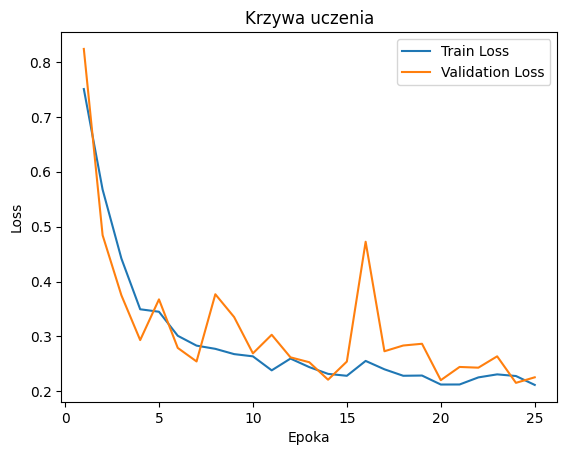

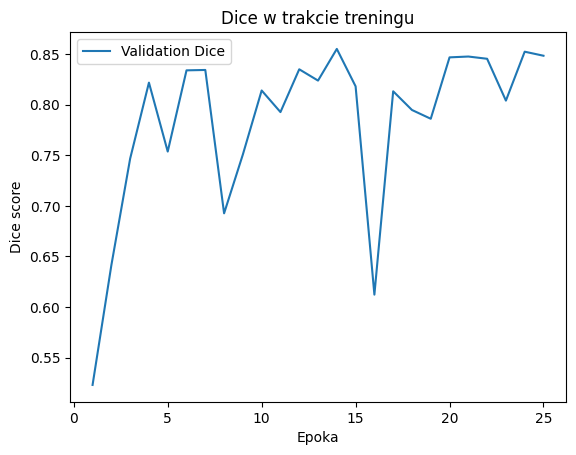

KeyboardInterrupt: 

In [46]:
DATA_DIR = 'C:/Users/jadwi/data-science-bowl-2018/stage1_train'

ids = os.listdir(DATA_DIR)
ids = sorted(ids)

train_ids, val_ids = train_test_split(
    ids,
    test_size=0.2,
    random_state=42
) 

mask_dir = os.path.join(DATA_DIR, sample_id, "masks")
mask_files = os.listdir(mask_dir)

combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)

for mf in mask_files:
    mask_path = os.path.join(mask_dir, mf)
    mask = np.array(Image.open(mask_path))
    combined_mask = np.maximum(combined_mask, mask)


mask_img = Image.open(mask_path).convert("L")
mask = np.array(mask_img, dtype=np.float32) / 255.0
mask = (mask > 0.5).astype(np.float32)

class KaggleDataset(Dataset):
    def __init__(self, ids, data_dir, img_size=256):
        self.ids = ids
        self.data_dir = data_dir
        self.img_size = img_size

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sid = self.ids[idx]
    
        img_path = os.path.join(
            self.data_dir, sid, "images", sid + ".png"
        )
    
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Brak obrazu: {img_path}")
    
        img = Image.open(img_path).convert("L")
        img = img.resize((self.img_size, self.img_size))
        img = np.array(img, dtype=np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)
    
        mask_dir = os.path.join(self.data_dir, sid, "masks")
    
        if not os.path.exists(mask_dir):
            raise FileNotFoundError(f"Brak folderu masek: {mask_dir}")
    
        mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
    
        for mf in os.listdir(mask_dir):
            m = Image.open(os.path.join(mask_dir, mf)).convert("L")
            m = m.resize((self.img_size, self.img_size))
            m = np.array(m) > 0
            mask = np.logical_or(mask, m)
    
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
    
        return img, mask

train_dataset = KaggleDataset(train_ids, DATA_DIR)
val_dataset   = KaggleDataset(val_ids, DATA_DIR)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        intersection = (probs * targets).sum(dim=(2,3))
        dice = (2. * intersection + self.smooth) / (
            probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth
        )
        dice_loss = 1 - dice.mean()

        bce = nn.functional.binary_cross_entropy(probs, targets, reduction='none')
        focal = self.alpha * (1 - torch.exp(-bce)) ** self.gamma * bce
        focal_loss = focal.mean()

        return dice_loss + focal_loss

class TestDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = load_test_image(self.image_paths[idx])
        return torch.tensor(img), self.image_paths[idx]


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1) 


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = FocalDiceLoss()


train_losses = []
val_losses = []
val_dice = []

num_epochs = 25

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f"Epoka {epoch+1}/{num_epochs}"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    model.eval()
    val_loss = 0.0
    dice_total = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model(imgs)
            val_loss += criterion(outputs, masks).item()
            dice_total += dice_score(outputs, masks).item()

    val_losses.append(val_loss / len(val_loader))
    val_dice.append(dice_total / len(val_loader))

    print(
        f"[Epoka {epoch+1}] "
        f"TrainLoss={train_losses[-1]:.4f}, "
        f"ValLoss={val_losses[-1]:.4f}, "
        f"FocalDiceLoss={val_dice[-1]:.4f}"
    )

epochs = range(1, num_epochs + 1)

plt.figure()

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.title("Krzywa uczenia")
plt.legend()

plt.show()

plt.figure()

plt.plot(epochs, val_dice, label="Validation Dice")

plt.xlabel("Epoka")
plt.ylabel("Dice score")
plt.title("Dice w trakcie treningu")
plt.legend()

plt.show()


results = []
IMG_SIZE = 256

def predict_mask(model_UNet, img_path, threshold=0.5):
    model_UNet.eval()
    img = load_test_image(img_path)
    with torch.no_grad():
        pred = model_UNet(img)

    pred = pred.squeeze().cpu().numpy()
    return (pred > threshold).astype(np.uint8)

for img_path in test_images:
    mask = predict_mask(model, img_path)

    results.append({
        "path": img_path,
    })

print(len(results))
for _ in range(5):
    r = random.choice(results)
    visualize_prediction(r["path"], predict_mask(model_UNet, r["path"]))


z augmentacją

In [75]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.3),

    A.Resize(128, 128),
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])

class KaggleDataset(Dataset):
    def __init__(self, ids, data_dir, transform=None):
        self.ids = ids
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sample_id = self.ids[idx]

        img_path = os.path.join(self.data_dir, sample_id, "images", sample_id + ".png")
        image = np.array(Image.open(img_path).convert("L"))

        mask_dir = os.path.join(self.data_dir, sample_id, "masks")
        mask_files = os.listdir(mask_dir)

        combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        for mf in mask_files:
            mask_path = os.path.join(mask_dir, mf)
            
            mask = Image.open(mask_path).convert("L")
            mask = mask.resize((image.shape[1], image.shape[0]))  # KLUCZOWE
            
            mask = np.array(mask)
            combined_mask = np.maximum(combined_mask, mask)

            
        mask = (combined_mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)

        return image, mask

Epoka 1/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [01:51<00:00,  1.22it/s]


[Epoka 1] TrainLoss=0.6914, ValLoss=0.8317, Dice=0.5878


Epoka 2/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [01:52<00:00,  1.20it/s]


[Epoka 2] TrainLoss=0.5296, ValLoss=0.3459, Dice=0.7885


Epoka 3/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [01:53<00:00,  1.19it/s]


...

[Epoka 10] TrainLoss=0.2960, ValLoss=0.2241, Dice=0.8583


Epoka 11/25: 100%|███████████████████████████████████████████████████████████████████| 136/136 [01:55<00:00,  1.17it/s]


[Epoka 11] TrainLoss=0.2871, ValLoss=0.2383, Dice=0.8449


Epoka 12/25: 100%|███████████████████████████████████████████████████████████████████| 136/136 [01:55<00:00,  1.17it/s]


[Epoka 12] TrainLoss=0.3286, ValLoss=0.2363, Dice=0.8516
Early stopping: brak poprawy


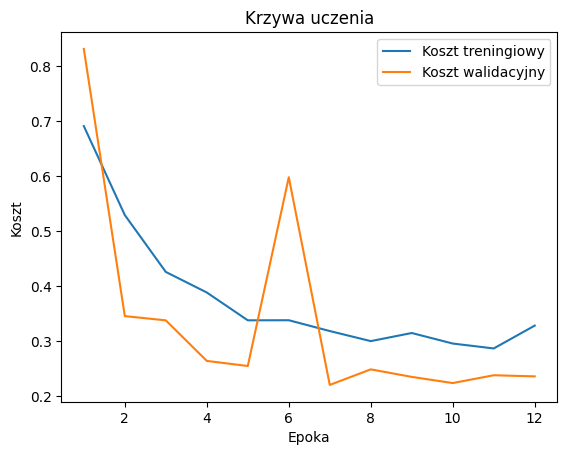

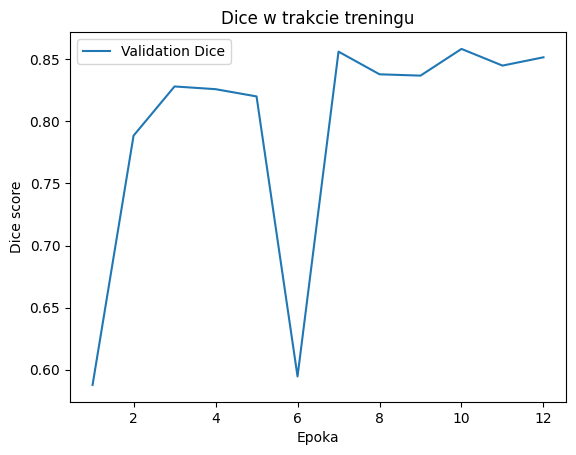

In [78]:
ids = os.listdir(DATA_DIR)
ids = sorted(ids)

train_ids, val_ids = train_test_split(
    ids,
    test_size=0.2,
    random_state=42
) 

mask_dir = os.path.join(DATA_DIR, sample_id, "masks")
mask_files = os.listdir(mask_dir)

combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)

for mf in mask_files:
    mask_path = os.path.join(mask_dir, mf)
    
    mask = Image.open(mask_path).convert("L")
    mask = mask.resize((image.shape[1], image.shape[0]))
    
    mask = np.array(mask)
    combined_mask = np.maximum(combined_mask, mask)


mask_img = Image.open(mask_path).convert("L")
mask = np.array(mask_img, dtype=np.float32) / 255.0
mask = (mask > 0.5).astype(np.float32)

train_dataset = KaggleDataset(train_ids, DATA_DIR, transform=train_transform)
val_dataset = KaggleDataset(val_ids, DATA_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        intersection = (probs * targets).sum(dim=(2,3))
        dice = (2. * intersection + self.smooth) / (
            probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth
        )
        dice_loss = 1 - dice.mean()

        bce = nn.functional.binary_cross_entropy(probs, targets, reduction='none')
        focal = self.alpha * (1 - torch.exp(-bce)) ** self.gamma * bce
        focal_loss = focal.mean()

        return dice_loss + focal_loss

class TestDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = load_test_image(self.image_paths[idx])
        return torch.tensor(img), self.image_paths[idx]


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1) 


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_UNet = UNet().to(device)
optimizer = torch.optim.Adam(model_UNet.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = FocalDiceLoss()

num_epochs = 25

best_val_loss = float("inf")
patience = 5
patience_counter = 0

loss_threshold = 0.005
dice_threshold = 0.98

train_losses = []
val_losses = []
val_dice = []

#epochs = range(1, len(train_losses) + 1)

for epoch in range(num_epochs):
    model_UNet.train()
    epoch_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f"Epoka {epoch+1}/{num_epochs}"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model_UNet(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)

    model_UNet.eval()
    val_loss = 0.0
    dice_total = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model_UNet(imgs)
            val_loss += criterion(outputs, masks).item()
            dice_total += dice_score(outputs, masks).item()

    val_loss /= len(val_loader)
    val_dice_score = dice_total / len(val_loader)

    val_losses.append(val_loss)
    val_dice.append(val_dice_score)

    print(
        f"[Epoka {epoch+1}] "
        f"TrainLoss={train_loss:.4f}, "
        f"ValLoss={val_loss:.4f}, "
        f"Dice={val_dice_score:.4f}"
    )

    #zapis najlepszego modelu
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_UNet.state_dict(), "najlepszy_model_UNet.pth")
    else:
        patience_counter += 1

    #warunek stop (threshold)
    if val_loss < loss_threshold or val_dice_score > dice_threshold:
        print("Early stopping: osiągnięto threshold")
        break

    #warunek stop (patience)
    if patience_counter >= patience:
        print("Early stopping: brak poprawy")
        break

epochs = range(1, len(train_losses) + 1)

plt.figure()

plt.plot(epochs, train_losses, label="Koszt treningiowy")
plt.plot(epochs, val_losses, label="Koszt walidacyjny")

plt.xlabel("Epoka")
plt.ylabel("Koszt")
plt.title("Krzywa uczenia")

plt.legend()

plt.show()

plt.figure()

plt.plot(epochs, val_dice, label="Validation Dice")

plt.xlabel("Epoka")
plt.ylabel("Dice score")
plt.title("Dice w trakcie treningu")
plt.legend()

plt.show()

In [ ]:
próba 2

Epoka 1/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [02:07<00:00,  1.07it/s]


[Epoka 1] TrainLoss=0.7233, ValLoss=0.6405, Dice=0.7820


Epoka 2/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [01:53<00:00,  1.20it/s]


[Epoka 2] TrainLoss=0.5466, ValLoss=0.4240, Dice=0.6778


Epoka 3/25: 100%|████████████████████████████████████████████████████████████████████| 136/136 [01:54<00:00,  1.19it/s]


...

[Epoka 13] TrainLoss=0.3331, ValLoss=0.2494, Dice=0.8484


Epoka 14/25: 100%|███████████████████████████████████████████████████████████████████| 136/136 [03:31<00:00,  1.55s/it]


[Epoka 14] TrainLoss=0.3293, ValLoss=0.2468, Dice=0.8254


Epoka 15/25: 100%|███████████████████████████████████████████████████████████████████| 136/136 [03:32<00:00,  1.57s/it]


[Epoka 15] TrainLoss=0.2999, ValLoss=0.2691, Dice=0.8489
Early stopping: brak poprawy


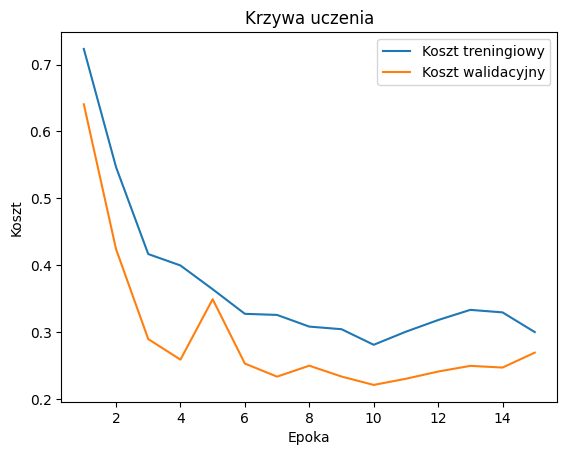

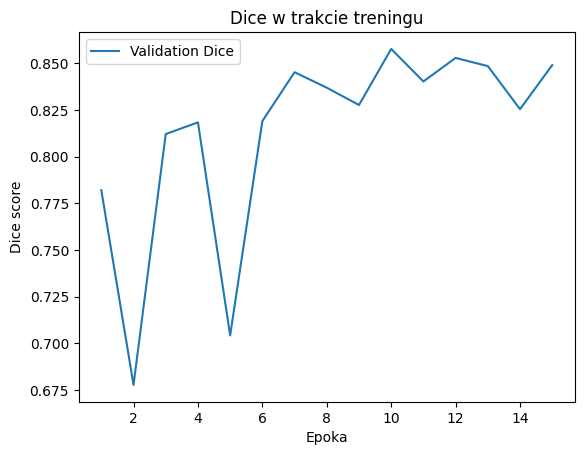

In [79]:
ids = os.listdir(DATA_DIR)
ids = sorted(ids)

train_ids, val_ids = train_test_split(
    ids,
    test_size=0.2,
    random_state=42
) 

mask_dir = os.path.join(DATA_DIR, sample_id, "masks")
mask_files = os.listdir(mask_dir)

combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)

for mf in mask_files:
    mask_path = os.path.join(mask_dir, mf)
    
    mask = Image.open(mask_path).convert("L")
    mask = mask.resize((image.shape[1], image.shape[0]))
    
    mask = np.array(mask)
    combined_mask = np.maximum(combined_mask, mask)


mask_img = Image.open(mask_path).convert("L")
mask = np.array(mask_img, dtype=np.float32) / 255.0
mask = (mask > 0.5).astype(np.float32)

train_dataset = KaggleDataset(train_ids, DATA_DIR, transform=train_transform)
val_dataset = KaggleDataset(val_ids, DATA_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        intersection = (probs * targets).sum(dim=(2,3))
        dice = (2. * intersection + self.smooth) / (
            probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth
        )
        dice_loss = 1 - dice.mean()

        bce = nn.functional.binary_cross_entropy(probs, targets, reduction='none')
        focal = self.alpha * (1 - torch.exp(-bce)) ** self.gamma * bce
        focal_loss = focal.mean()

        return dice_loss + focal_loss

class TestDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = load_test_image(self.image_paths[idx])
        return torch.tensor(img), self.image_paths[idx]


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1) 


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_UNet = UNet().to(device)
optimizer = torch.optim.Adam(model_UNet.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = FocalDiceLoss()

num_epochs = 25

best_val_loss = float("inf")
patience = 5
patience_counter = 0

loss_threshold = 0.001
dice_threshold = 0.99

train_losses = []
val_losses = []
val_dice = []

#epochs = range(1, len(train_losses) + 1)

for epoch in range(num_epochs):
    model_UNet.train()
    epoch_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f"Epoka {epoch+1}/{num_epochs}"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model_UNet(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)

    model_UNet.eval()
    val_loss = 0.0
    dice_total = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model_UNet(imgs)
            val_loss += criterion(outputs, masks).item()
            dice_total += dice_score(outputs, masks).item()

    val_loss /= len(val_loader)
    val_dice_score = dice_total / len(val_loader)

    val_losses.append(val_loss)
    val_dice.append(val_dice_score)

    print(
        f"[Epoka {epoch+1}] "
        f"TrainLoss={train_loss:.4f}, "
        f"ValLoss={val_loss:.4f}, "
        f"Dice={val_dice_score:.4f}"
    )

    #zapis najlepszego modelu
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_UNet.state_dict(), "najlepszy_model_UNet.pth")
    else:
        patience_counter += 1

    #warunek stop (threshold)
    if val_loss < loss_threshold or val_dice_score > dice_threshold:
        print("Early stopping: osiągnięto threshold")
        break

    #warunek stop (patience)
    if patience_counter >= patience:
        print("Early stopping: brak poprawy")
        break

epochs = range(1, len(train_losses) + 1)

plt.figure()

plt.plot(epochs, train_losses, label="Koszt treningiowy")
plt.plot(epochs, val_losses, label="Koszt walidacyjny")

plt.xlabel("Epoka")
plt.ylabel("Koszt")
plt.title("Krzywa uczenia")

plt.legend()

plt.show()

plt.figure()

plt.plot(epochs, val_dice, label="Validation Dice")

plt.xlabel("Epoka")
plt.ylabel("Dice score")
plt.title("Dice w trakcie treningu")
plt.legend()

plt.show()

Generacja masek

100%|██████████████████████████████████████████████████████████████████████████| 30151/30151 [2:01:32<00:00,  4.13it/s]


30151


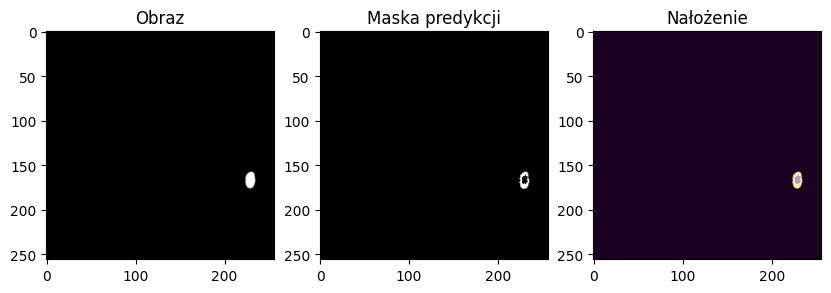

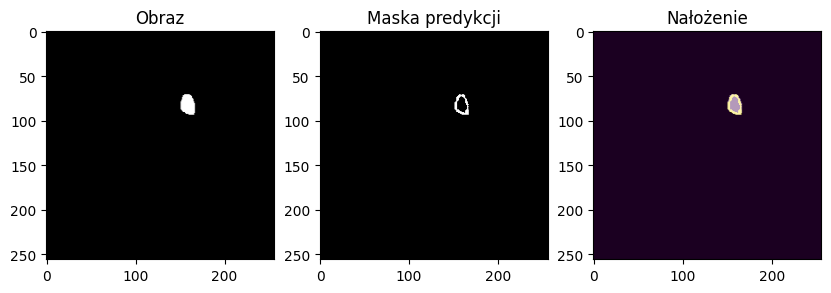

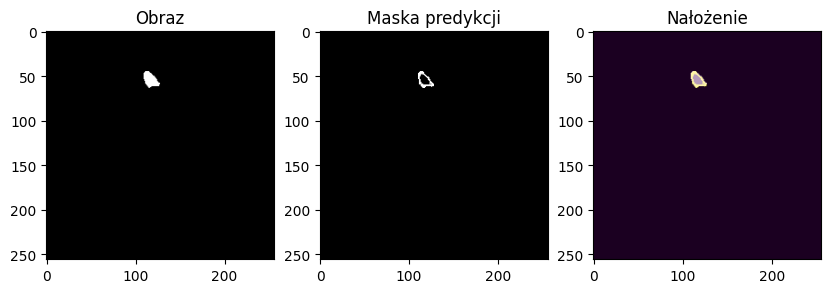

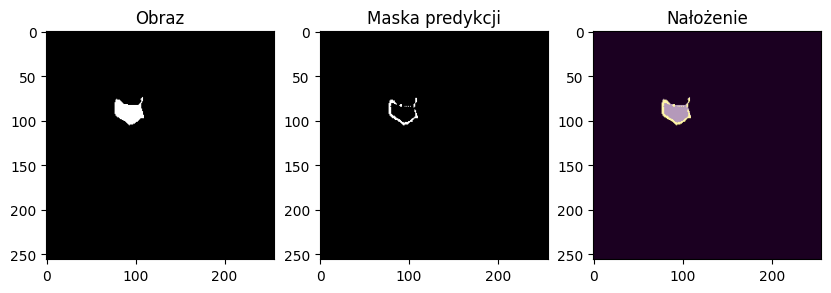

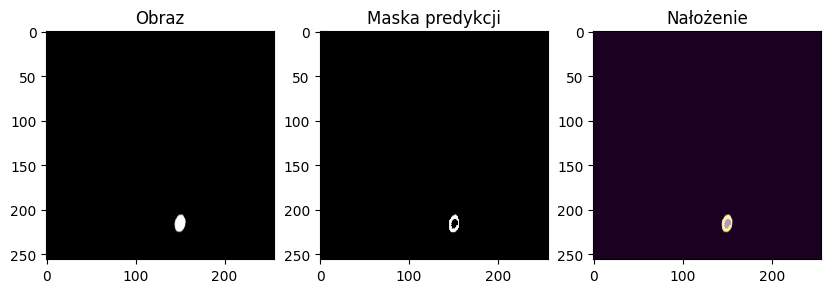

In [81]:
results = []
IMG_SIZE = 256

def predict_mask(model_UNet, img_path, threshold=0.5):
    model_UNet.eval()
    img = load_test_image(img_path)
    with torch.no_grad():
        pred = model_UNet(img)

    pred = pred.squeeze().cpu().numpy()
    return (pred > threshold).astype(np.uint8)

for img_path in tqdm(test_images):
    mask = predict_mask(model, img_path)

    results.append({
        "path": img_path,
        "mask": mask
    })

print(len(results))
for _ in range(5):
    r = random.choice(results)
    visualize_prediction(r["path"], r["mask"])

In [53]:
print("Liczba wyników:", len(results))

Liczba wyników: 5


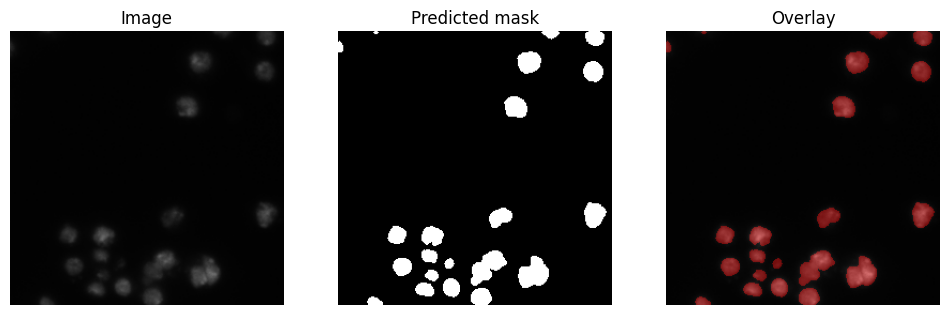

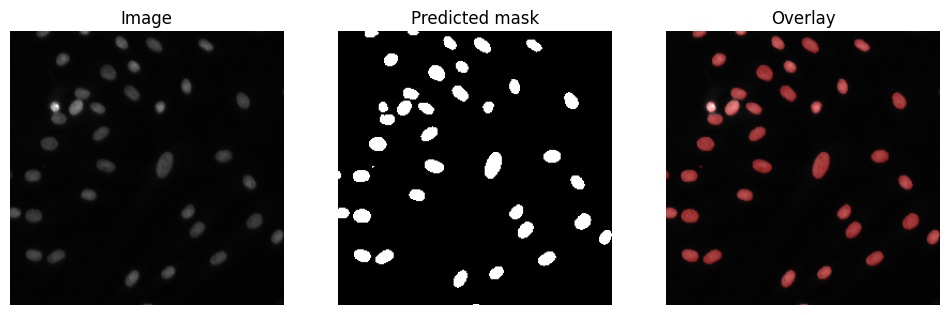

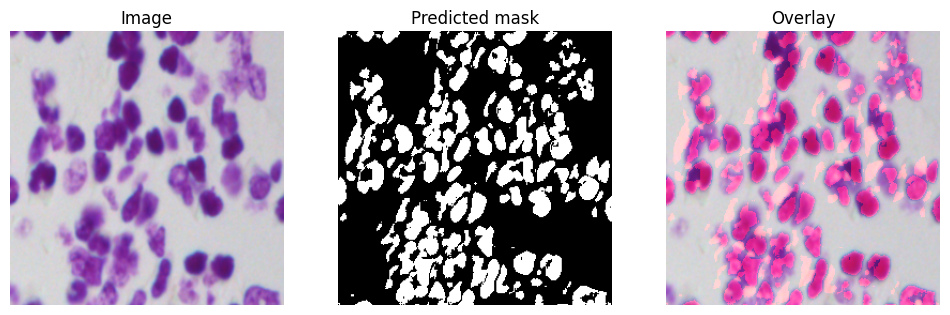

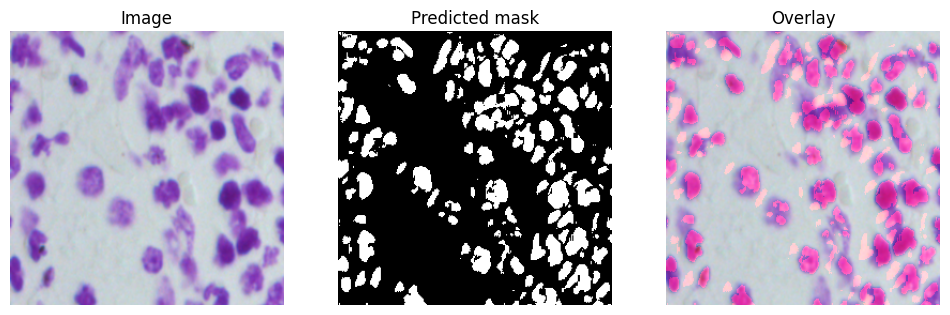

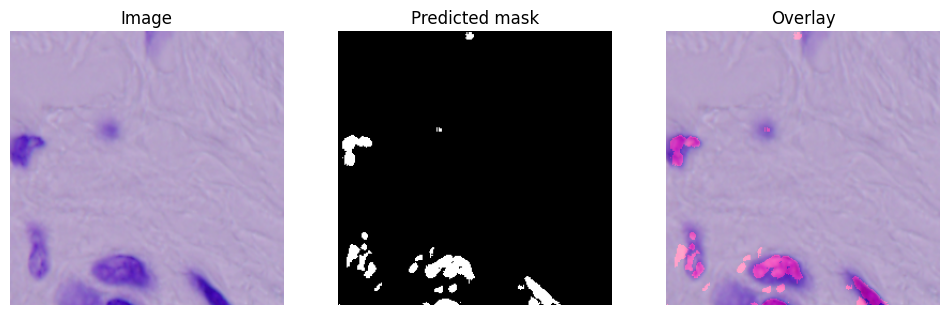

In [82]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

def load_true_mask(mask_dir):
    masks = []
    for file in os.listdir(mask_dir):
        m = Image.open(os.path.join(mask_dir, file)).convert("L")
        m = m.resize((IMG_SIZE, IMG_SIZE))
        masks.append(np.array(m))

    return np.max(masks, axis=0)  # łączenie masek


    
def overlay_mask(image, mask, alpha=0.4):
    # maska na czerwono
    colored_mask = np.zeros_like(image)
    colored_mask[:, :, 0] = mask * 255  # czerwony kanał

    return cv2.addWeighted(image, 1.0, colored_mask, alpha, 0)



for img_path, mask_dir in pairs:
    # wczytaj obraz
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # predykcja
    pred_mask = predict_mask(model_UNet, img_path)

    # nałożenie maski
    overlay = overlay_mask(image, pred_mask)

    # wizualizacja
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Predicted mask")
    plt.imshow(pred_mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

In [104]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMG_SIZE = 256

def load_true_mask(mask_dir):
    masks = []
    for file in os.listdir(mask_dir):
        m = Image.open(os.path.join(mask_dir, file)).convert("L")
        m = m.resize((IMG_SIZE, IMG_SIZE))
        masks.append(np.array(m))

    return np.max(masks, axis=0)


def overlay_mask(image, mask, alpha=0.4):
    colored_mask = np.zeros_like(image)
    colored_mask[:, :, 0] = mask * 255  # czerwony

    return cv2.addWeighted(image, 1.0, colored_mask, alpha, 0)


DATA_DIR = Path(r"C:\Users\jadwi\OneDrive\Pulpit\Studia\Bioinformatyka II UJ\Praca magisterska\dane")

# znajdź wszystkie obrazy
test_images = list(DATA_DIR.rglob("*.jpg"))

# losuj 5
sample_images = random.sample(test_images, 5)

# buduj pairs
pairs = []

for img_path, mask_dir in pairs:

    image = cv2.imread(img_path)

    if image is None:
        print(f"Błąd wczytywania: {img_path}")
        continue

    if not os.path.exists(mask_dir):
        print(f"Brak maski dla: {img_path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    pred_mask = predict_mask(model_UNet, img_path)
    true_mask = load_true_mask(mask_dir)

    overlay_pred = overlay_mask(image, pred_mask)
    overlay_true = overlay_mask(image, true_mask)

    plt.figure(figsize=(15,5))

    plt.subplot(1,5,1)
    plt.title("Image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.title("GT mask")
    plt.imshow(true_mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.title("Pred mask")
    plt.imshow(pred_mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,5,4)
    plt.title("GT overlay")
    plt.imshow(overlay_true)
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.title("Pred overlay")
    plt.imshow(overlay_pred)
    plt.axis("off")

    plt.show()

In [102]:
DATA_DIR = Path(r"C:\Users\jadwi\OneDrive\Pulpit\Studia\Bioinformatyka II UJ\Praca magisterska\dane")

test_images = sorted(DATA_DIR.rglob("*.jpg"))

print(f"Znaleziono {len(test_images)} obrazów")
print("Przykłady:")
for p in test_images[:5]:
    print(p)


Znaleziono 1090 obrazów
Przykłady:
C:\Users\jadwi\OneDrive\Pulpit\Studia\Bioinformatyka II UJ\Praca magisterska\dane\A01\POINT_00001\SCAN 00001\00001.JPG
C:\Users\jadwi\OneDrive\Pulpit\Studia\Bioinformatyka II UJ\Praca magisterska\dane\A01\POINT_00001\SCAN 00001\STITCH.jpg
C:\Users\jadwi\OneDrive\Pulpit\Studia\Bioinformatyka II UJ\Praca magisterska\dane\A01\POINT_00001\SCAN 00002\00001.JPG
C:\Users\jadwi\OneDrive\Pulpit\Studia\Bioinformatyka II UJ\Praca magisterska\dane\A01\POINT_00001\SCAN 00002\STITCH.jpg
C:\Users\jadwi\OneDrive\Pulpit\Studia\Bioinformatyka II UJ\Praca magisterska\dane\A01\POINT_00001\SCAN 00003\00001.JPG


In [101]:
print(pairs[0][0])
print(os.path.exists(pairs[0][0]))

C:\Users\jadwi\data-science-bowl-2018\stage1_train\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e\images\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e.png
True


In [99]:
print(img_path)
print(os.path.exists(img_path))

C:\Users\jadwi\data-science-bowl-2018\stage1_train\00ae65...\images\00ae65....png
False


In [105]:
import cv2

def count_cells(mask):
    mask = mask.astype(np.uint8)

    num_labels, _ = cv2.connectedComponents(mask)

    return num_labels - 1  # bez tła

In [109]:
OUT_DIR = Path(r"C:\Users\jadwi\OneDrive\Pulpit\Studia\Bioinformatyka II UJ\Praca magisterska\maski")

for img_path in tqdm(test_images):
    rel = img_path.relative_to(DATA_DIR)
    out_path = OUT_DIR / rel
    out_path = out_path.with_name(out_path.stem + "_mask.png")

    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.imsave(out_path, (mask * 255).astype(np.uint8))
    
IMG_SIZE = 256
BATCH_SIZE = 4
NUM_EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████████████████████████████████████████████████████████████████████████| 1090/1090 [00:24<00:00, 44.34it/s]


#### Metryki ewaluacyjne

In [52]:
pairs = [ (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e\images\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e.png",r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e\masks"), 
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e\images\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e\masks"), 
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9\images\3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9\masks"),
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\8d9b4205ddb10fa49a2973b4f3a2dc6923407ae015081e1a52c4b4c2fe8faa53\images\8d9b4205ddb10fa49a2973b4f3a2dc6923407ae015081e1a52c4b4c2fe8faa53.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\8d9b4205ddb10fa49a2973b4f3a2dc6923407ae015081e1a52c4b4c2fe8faa53\masks"),
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\b0d6dfcc95e4d087d232378f860fc3ef9f95ea5a4c26d623a0be091f820a793f\images\b0d6dfcc95e4d087d232378f860fc3ef9f95ea5a4c26d623a0be091f820a793f.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\b0d6dfcc95e4d087d232378f860fc3ef9f95ea5a4c26d623a0be091f820a793f\masks")
        ]

pairs = []

for sid in ids[:5]:
    img_path = os.path.join(DATA_DIR, sid, "images", sid + ".png")
    mask_dir = os.path.join(DATA_DIR, sid, "masks")

    pairs.append((img_path, mask_dir))

from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def dice_coef(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(y_true * y_pred)
    return (2 * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)
    
dice = dice_coef(y_true.flatten(), y_pred.flatten())
iou = dice / (2 - dice)
precision, recall, _, _ = precision_recall_fscore_support(y_true.flatten(), y_pred.flatten(), average='binary')

print(f"Dice: {dice:.3f}, IoU: {iou:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

results = []

for img_path, mask_dir in pairs:

    pred_mask = predict_mask(model, img_path)
    true_mask = load_combined_mask(mask_dir)

    y_pred = pred_mask.flatten()
    y_true = true_mask.flatten()

    dice = dice_coef(y_true, y_pred)
    iou = iou_score(y_true, y_pred)

    precision, recall, _, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    results.append({
        "path": img_path,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall
    })

df = pd.DataFrame(results)
print(df)
print("\nŚrednie wyniki:")
print(df[["dice", "iou", "precision", "recall"]].mean())

Dice: 0.424, IoU: 0.269, Precision: 0.998, Recall: 0.269
                                                path      dice       iou  \
0  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.893095  0.806839   
1  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.948437  0.901930   
2  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.707334  0.547191   
3  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.689068  0.525632   
4  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.424093  0.269111   

   precision    recall  
0   0.961275  0.833946  
1   0.930705  0.966857  
2   0.986890  0.551197  
3   0.920578  0.550600  
4   0.998454  0.269223  

Średnie wyniki:
dice         0.732405
iou          0.610140
precision    0.959580
recall       0.634365
dtype: float64


Zapis masek do pliku

In [ ]:
OUT_DIR = Path(r"C:/cellpose_output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def predict_mask_unet(model, img_path, img_size=256, threshold=0.5):
    model.eval()

    img = Image.open(img_path).convert("L")
    img = img.resize((img_size, img_size))
    img = np.array(img, dtype=np.float32) / 255.0
    img = torch.tensor(img).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img)
        probs = torch.sigmoid(logits)

    mask = (probs > threshold).float()
    mask = mask.squeeze().cpu().numpy()

    return mask

for img_path in tqdm(test_images, desc="Zapis masek"):
    mask = predict_mask_unet(model, img_path)

    img_path = Path(img_path)
    out_name = img_path.stem + "_mask.png"
    out_path = OUT_DIR / out_name

    imsave(
        out_path,
        (mask * 255).astype(np.uint8),
        check_contrast=False
    )

print("Maski zapisane")

Ewaluacja po augmentacji

In [80]:
pairs = [ (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e\images\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e.png",r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e\masks"), 
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e\images\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e\masks"), 
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9\images\3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9\masks"),
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\8d9b4205ddb10fa49a2973b4f3a2dc6923407ae015081e1a52c4b4c2fe8faa53\images\8d9b4205ddb10fa49a2973b4f3a2dc6923407ae015081e1a52c4b4c2fe8faa53.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\8d9b4205ddb10fa49a2973b4f3a2dc6923407ae015081e1a52c4b4c2fe8faa53\masks"),
         (r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\b0d6dfcc95e4d087d232378f860fc3ef9f95ea5a4c26d623a0be091f820a793f\images\b0d6dfcc95e4d087d232378f860fc3ef9f95ea5a4c26d623a0be091f820a793f.png", r"C:\Users\jadwi\data-science-bowl-2018\stage1_train\b0d6dfcc95e4d087d232378f860fc3ef9f95ea5a4c26d623a0be091f820a793f\masks")
        ]

pairs = []

for sid in ids[:5]:
    img_path = os.path.join(DATA_DIR, sid, "images", sid + ".png")
    mask_dir = os.path.join(DATA_DIR, sid, "masks")

    pairs.append((img_path, mask_dir))

from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def dice_coef(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(y_true * y_pred)
    return (2 * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)
    
dice = dice_coef(y_true.flatten(), y_pred.flatten())
iou = dice / (2 - dice)
precision, recall, _, _ = precision_recall_fscore_support(y_true.flatten(), y_pred.flatten(), average='binary')

print(f"Dice: {dice:.3f}, IoU: {iou:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

results = []

for img_path, mask_dir in pairs:

    pred_mask = predict_mask(model, img_path)
    true_mask = load_combined_mask(mask_dir)

    y_pred = pred_mask.flatten()
    y_true = true_mask.flatten()

    dice = dice_coef(y_true, y_pred)
    iou = iou_score(y_true, y_pred)

    precision, recall, _, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    results.append({
        "path": img_path,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall
    })

df = pd.DataFrame(results)
print(df)
print("\nŚrednie wyniki:")
print(df[["dice", "iou", "precision", "recall"]].mean())

Dice: 0.812, IoU: 0.684, Precision: 0.908, Recall: 0.735
                                                path      dice       iou  \
0  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.761362  0.614677   
1  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.883867  0.791900   
2  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.352955  0.214296   
3  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.260017  0.149436   
4  C:/Users/jadwi/data-science-bowl-2018/stage1_t...  0.534087  0.364337   

   precision    recall  
0   0.958068  0.631671  
1   0.823669  0.953557  
2   0.667254  0.239937  
3   0.413511  0.189627  
4   0.598191  0.482392  

Średnie wyniki:
dice         0.558458
iou          0.426929
precision    0.692139
recall       0.499437
dtype: float64
